In [7]:
import sys

In [8]:
print(sys.executable)
print(sys.version)

c:\Users\xinyue\anaconda3\python.exe
3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [9]:
!{sys.executable} -m pip install eclipse-sumo traci sumolib stable-baselines3 gymnasium torch numpy pandas matplotlib sb3-contrib tensorboard


In [10]:
import os
import time
import traci
import random
import shutil
import subprocess
import numpy as np
import pandas as pd
import gymnasium as gym
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from gymnasium import spaces
from sb3_contrib import QRDQN
from stable_baselines3 import DQN, A2C, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback



In [11]:
# =========================================================
# Cell 1: SUMO setup
# =========================================================
NETCONVERT = shutil.which("netconvert")
SUMO = shutil.which("sumo")
SUMO_GUI = shutil.which("sumo-gui")

if NETCONVERT is None:
    raise RuntimeError("netconvert not found. Please make sure SUMO is installed and added to PATH.")
if SUMO is None:
    raise RuntimeError("sumo not found. Please make sure SUMO is installed and added to PATH.")
if SUMO_GUI is None:
    raise RuntimeError("sumo-gui not found. Please make sure SUMO is installed and added to PATH.")



In [12]:
# =========================================================
# Cell 2: Create SUMO network files
# =========================================================
base_dir = os.path.abspath("sumo_files")
os.makedirs(base_dir, exist_ok=True)

nodes_file = os.path.join(base_dir, "cross.nod.xml")
edges_file = os.path.join(base_dir, "cross.edg.xml")
con_file   = os.path.join(base_dir, "cross.con.xml")
net_file   = os.path.join(base_dir, "cross.net.xml")
route_file = os.path.join(base_dir, "cross.rou.xml")
cfg_file   = os.path.join(base_dir, "cross.sumocfg")

In [13]:
# =========================================================
# Cell 3: NETWORK DESIGN
# - Only center node C is traffic_light
# - Outer nodes are priority nodes
# - 3 lanes per incoming edge:
#     lane 1 = left
#     lane 2 = straight
#     lane 3 = right
# - sidewalks added to support pedestrian movement
# - crossings will be generated automatically by netconvert
# =========================================================

nodes_content = """<nodes>
    <node id="N" x="0" y="200" type="priority"/>
    <node id="S" x="0" y="-200" type="priority"/>
    <node id="E" x="200" y="0" type="priority"/>
    <node id="W" x="-200" y="0" type="priority"/>
    <node id="C" x="0" y="0" type="traffic_light" radius="10"/>
</nodes>
"""

edges_content = """<edges>
    <edge id="N2C" from="N" to="C" numLanes="3" speed="8.33" sidewalkWidth="2"/>
    <edge id="C2N" from="C" to="N" numLanes="3" speed="8.33" sidewalkWidth="2"/>

    <edge id="S2C" from="S" to="C" numLanes="3" speed="8.33" sidewalkWidth="2"/>
    <edge id="C2S" from="C" to="S" numLanes="3" speed="8.33" sidewalkWidth="2"/>

    <edge id="E2C" from="E" to="C" numLanes="3" speed="8.33" sidewalkWidth="2"/>
    <edge id="C2E" from="C" to="E" numLanes="3" speed="8.33" sidewalkWidth="2"/>

    <edge id="W2C" from="W" to="C" numLanes="3" speed="8.33" sidewalkWidth="2"/>
    <edge id="C2W" from="C" to="W" numLanes="3" speed="8.33" sidewalkWidth="2"/>
</edges>
"""

connections_content = """<connections>
    <!-- lane 1 = left, lane 2 = straight, lane 3 = right -->

    <!-- From North -->
    <connection from="N2C" to="C2E" fromLane="1" toLane="1"/>  <!-- left -->
    <connection from="N2C" to="C2S" fromLane="2" toLane="2"/>  <!-- straight -->
    <connection from="N2C" to="C2W" fromLane="3" toLane="3"/>  <!-- right -->

    <!-- From South -->
    <connection from="S2C" to="C2W" fromLane="1" toLane="1"/>  <!-- left -->
    <connection from="S2C" to="C2N" fromLane="2" toLane="2"/>  <!-- straight -->
    <connection from="S2C" to="C2E" fromLane="3" toLane="3"/>  <!-- right -->

    <!-- From East -->
    <connection from="E2C" to="C2S" fromLane="1" toLane="1"/>  <!-- left -->
    <connection from="E2C" to="C2W" fromLane="2" toLane="2"/>  <!-- straight -->
    <connection from="E2C" to="C2N" fromLane="3" toLane="3"/>  <!-- right -->

    <!-- From West -->
    <connection from="W2C" to="C2N" fromLane="1" toLane="1"/>  <!-- left -->
    <connection from="W2C" to="C2E" fromLane="2" toLane="2"/>  <!-- straight -->
    <connection from="W2C" to="C2S" fromLane="3" toLane="3"/>  <!-- right -->
</connections>
"""

with open(nodes_file, "w") as f:
    f.write(nodes_content)

with open(edges_file, "w") as f:
    f.write(edges_content)

with open(con_file, "w") as f:
    f.write(connections_content)

print("Created:")
print(nodes_file)
print(edges_file)
print(con_file)

Created:
c:\Users\xinyue\Desktop\ML (10)\ML\sumo_files\cross.nod.xml
c:\Users\xinyue\Desktop\ML (10)\ML\sumo_files\cross.edg.xml
c:\Users\xinyue\Desktop\ML (10)\ML\sumo_files\cross.con.xml


In [14]:
# =========================================================
# Cell 4: Build SUMO network
# =========================================================
cmd = [
    NETCONVERT,
    "--node-files", nodes_file,
    "--edge-files", edges_file,
    "--connection-files", con_file,
    "--default.sidewalk-width", "2.0",
    "--crossings.guess",
    "--walkingareas",
    "--default.crossing-width", "4.0",
    "--junctions.corner-detail", "3",
    "--lefthand",
    "--tls.guess-signals",
    "--tls.discard-simple",
    "--output-file", net_file
]

result = subprocess.run(cmd, capture_output=True, text=True)

print("Return code:", result.returncode)
print("STDOUT:")
print(result.stdout)
print("STDERR:")
print(result.stderr)
print("Network file exists:", os.path.exists(net_file))

Return code: 0
STDOUT:
Success.

STDERR:

Network file exists: True


In [15]:
# =========================================================
# Cell 5: Verify generated network file
# - Check for crossing and walkingarea edges
# =========================================================

tree = ET.parse(net_file)
root = tree.getroot()

edges = root.findall(".//edge")

crossing_edges = [e.attrib for e in edges if e.attrib.get("function") == "crossing"]
walkingarea_edges = [e.attrib for e in edges if e.attrib.get("function") == "walkingarea"]

print("Number of crossing edges found:", len(crossing_edges))
for i, c in enumerate(crossing_edges[:10]):
    print(f"Crossing edge {i}: {c}")

print("\nNumber of walkingarea edges found:", len(walkingarea_edges))
for i, w in enumerate(walkingarea_edges[:10]):
    print(f"Walkingarea edge {i}: {w}")

Number of crossing edges found: 4
Crossing edge 0: {'id': ':C_c0', 'function': 'crossing', 'crossingEdges': 'C2S S2C'}
Crossing edge 1: {'id': ':C_c1', 'function': 'crossing', 'crossingEdges': 'C2E E2C'}
Crossing edge 2: {'id': ':C_c2', 'function': 'crossing', 'crossingEdges': 'C2N N2C'}
Crossing edge 3: {'id': ':C_c3', 'function': 'crossing', 'crossingEdges': 'C2W W2C'}

Number of walkingarea edges found: 8
Walkingarea edge 0: {'id': ':C_w0', 'function': 'walkingarea'}
Walkingarea edge 1: {'id': ':C_w1', 'function': 'walkingarea'}
Walkingarea edge 2: {'id': ':C_w2', 'function': 'walkingarea'}
Walkingarea edge 3: {'id': ':C_w3', 'function': 'walkingarea'}
Walkingarea edge 4: {'id': ':E_w0', 'function': 'walkingarea'}
Walkingarea edge 5: {'id': ':N_w0', 'function': 'walkingarea'}
Walkingarea edge 6: {'id': ':S_w0', 'function': 'walkingarea'}
Walkingarea edge 7: {'id': ':W_w0', 'function': 'walkingarea'}


In [16]:
# =========================================================
# Cell 6: Create route and config files
# - Define vehicle types, routes, and flows
# - Define pedestrian flows across the intersection
# =========================================================

route_content = """<routes>
    <vType id="sedan"
        vClass="passenger"
        guiShape="passenger/sedan"
        color="random"
        length="4.5"
        width="1.8"
        maxSpeed="13.89"/>

    <vType id="van"
        vClass="passenger"
        guiShape="passenger/van"
        color="random"
        length="5.5"
        width="2.1"
        maxSpeed="12.0"/>

    <vType id="lorry"
        vClass="truck"
        guiShape="truck"
        color="random"
        length="8.0"
        width="2.5"
        maxSpeed="10.0"/>
            
    <!-- Routes -->
    <route id="north_left"     edges="N2C C2E"/>
    <route id="north_straight" edges="N2C C2S"/>
    <route id="north_right"    edges="N2C C2W"/>

    <route id="south_left"     edges="S2C C2W"/>
    <route id="south_straight" edges="S2C C2N"/>
    <route id="south_right"    edges="S2C C2E"/>

    <route id="east_left"      edges="E2C C2S"/>
    <route id="east_straight"  edges="E2C C2W"/>
    <route id="east_right"     edges="E2C C2N"/>

    <route id="west_left"      edges="W2C C2N"/>
    <route id="west_straight"  edges="W2C C2E"/>
    <route id="west_right"     edges="W2C C2S"/>

    <!-- Vehicle flows -->
    <!-- lane 1 = left, lane 2 = straight, lane 3 = right -->

    <flow id="f_n_left_sedan" type="sedan" route="north_left" begin="0" end="1200" probability="0.04" departLane="1"/>
    <flow id="f_n_left_van"   type="van"   route="north_left" begin="0" end="1200" probability="0.02" departLane="1"/>
    <flow id="f_n_left_lorry" type="lorry" route="north_left" begin="0" end="1200" probability="0.01" departLane="1"/>
    <flow id="f_n_straight_sedan" type="sedan" route="north_straight" begin="0" end="1200" probability="0.04" departLane="2"/>
    <flow id="f_n_straight_van"   type="van"   route="north_straight" begin="0" end="1200" probability="0.02" departLane="2"/>
    <flow id="f_n_straight_lorry" type="lorry" route="north_straight" begin="0" end="1200" probability="0.01" departLane="2"/>
    <flow id="f_n_right_sedan" type="sedan" route="north_right" begin="0" end="1200" probability="0.03" departLane="3"/>
    <flow id="f_n_right_van"   type="van"   route="north_right" begin="0" end="1200" probability="0.02" departLane="3"/>
    <flow id="f_n_right_lorry" type="lorry" route="north_right" begin="0" end="1200" probability="0.01" departLane="3"/>

    
    <flow id="f_s_left_sedan" type="sedan" route="south_left" begin="0" end="1200" probability="0.04" departLane="1"/>
    <flow id="f_s_left_van"   type="van"   route="south_left" begin="0" end="1200" probability="0.02" departLane="1"/>
    <flow id="f_s_left_lorry" type="lorry" route="south_left" begin="0" end="1200" probability="0.01" departLane="1"/>
    <flow id="f_s_straight_sedan" type="sedan" route="south_straight" begin="0" end="1200" probability="0.04" departLane="2"/>
    <flow id="f_s_straight_van"   type="van"   route="south_straight" begin="0" end="1200" probability="0.02" departLane="2"/>
    <flow id="f_s_straight_lorry" type="lorry" route="south_straight" begin="0" end="1200" probability="0.01" departLane="2"/>
    <flow id="f_s_right_sedan" type="sedan" route="south_right" begin="0" end="1200" probability="0.03" departLane="3"/>
    <flow id="f_s_right_van"   type="van"   route="south_right" begin="0" end="1200" probability="0.02" departLane="3"/>
    <flow id="f_s_right_lorry" type="lorry" route="south_right" begin="0" end="1200" probability="0.01" departLane="3"/>

    <flow id="f_e_left_sedan" type="sedan" route="east_left" begin="0" end="1200" probability="0.04" departLane="1"/>
    <flow id="f_e_left_van"   type="van"   route="east_left" begin="0" end="1200" probability="0.02" departLane="1"/>
    <flow id="f_e_left_lorry" type="lorry" route="east_left" begin="0" end="1200" probability="0.01" departLane="1"/>
    <flow id="f_e_straight_sedan" type="sedan" route="east_straight" begin="0" end="1200" probability="0.04" departLane="2"/>
    <flow id="f_e_straight_van"   type="van"   route="east_straight" begin="0" end="1200" probability="0.02" departLane="2"/>
    <flow id="f_e_straight_lorry" type="lorry" route="east_straight" begin="0" end="1200" probability="0.01" departLane="2"/>
    <flow id="f_e_right_sedan" type="sedan" route="east_right" begin="0" end="1200" probability="0.03" departLane="3"/>
    <flow id="f_e_right_van"   type="van"   route="east_right" begin="0" end="1200" probability="0.02" departLane="3"/>
    <flow id="f_e_right_lorry" type="lorry" route="east_right" begin="0" end="1200" probability="0.01" departLane="3"/>

    <flow id="f_w_left_sedan" type="sedan" route="west_left" begin="0" end="1200" probability="0.04" departLane="1"/>
    <flow id="f_w_left_van"   type="van"   route="west_left" begin="0" end="1200" probability="0.02" departLane="1"/>
    <flow id="f_w_left_lorry" type="lorry" route="west_left" begin="0" end="1200" probability="0.01" departLane="1"/>
    <flow id="f_w_straight_sedan" type="sedan" route="west_straight" begin="0" end="1200" probability="0.04" departLane="2"/>
    <flow id="f_w_straight_van"   type="van"   route="west_straight" begin="0" end="1200" probability="0.02" departLane="2"/>
    <flow id="f_w_straight_lorry" type="lorry" route="west_straight" begin="0" end="1200" probability="0.01" departLane="2"/>
    <flow id="f_w_right_sedan" type="sedan" route="west_right" begin="0" end="1200" probability="0.03" departLane="3"/>
    <flow id="f_w_right_van"   type="van"   route="west_right" begin="0" end="1200" probability="0.02" departLane="3"/>
    <flow id="f_w_right_lorry" type="lorry" route="west_right" begin="0" end="1200" probability="0.01" departLane="3"/>

 
    <!-- Pedestrians -->
    <personFlow id="ped_w_to_e" begin="0" end="1200" probability="0.03">
        <walk from="W2C" to="E2C"/>
    </personFlow>

    <personFlow id="ped_e_to_w" begin="0" end="1200" probability="0.03">
        <walk from="E2C" to="W2C"/>
    </personFlow>

    <personFlow id="ped_n_to_s" begin="0" end="1200" probability="0.03">
        <walk from="N2C" to="S2C"/>
    </personFlow>

    <personFlow id="ped_s_to_n" begin="0" end="1200" probability="0.03">
        <walk from="S2C" to="N2C"/>
    </personFlow>
</routes>
"""

cfg_content = """<configuration>
    <input>
        <net-file value="cross.net.xml"/>
        <route-files value="cross.rou.xml"/>
    </input>
    
    <gui_only>
        <gui-settings-file value="view.xml"/>
    </gui_only>

    <time>
        <begin value="0"/>
        <end value="600"/>
    </time>

    <processing>
        <step-length value="1.0"/>
    </processing>
</configuration>
"""

with open(route_file, "w") as f:
    f.write(route_content)

with open(cfg_file, "w") as f:
    f.write(cfg_content)

print("Created:")
print(route_file)
print(cfg_file)

Created:
c:\Users\xinyue\Desktop\ML (10)\ML\sumo_files\cross.rou.xml
c:\Users\xinyue\Desktop\ML (10)\ML\sumo_files\cross.sumocfg


In [17]:
# =========================================================
# Cell 7: Inspect actual TLS state length
# =========================================================

if traci.isLoaded():
    traci.close()

traci.start([SUMO, "-c", cfg_file])

tls_ids = traci.trafficlight.getIDList()
print("Traffic light IDs:", tls_ids)

tls_id = tls_ids[0]

current_state = traci.trafficlight.getRedYellowGreenState(tls_id)
controlled_links = traci.trafficlight.getControlledLinks(tls_id)

print("Current TLS state:", current_state)
print("Required phase length:", len(current_state))
print("Controlled link count:", len(controlled_links))

print("\nControlled links:")
for i, group in enumerate(controlled_links):
    if len(group) == 0:
        print(f"{i}: EMPTY")
        continue

    from_lane = group[0][0]

    if from_lane.startswith(":"):
        link_type = "Pedestrian/Internal"
    else:
        link_type = "Vehicle"

    print(f"{i}: {group} → {link_type}")

traci.close()

Traffic light IDs: ('C',)
Current TLS state: gGgrrrgGgrrrrGrG
Required phase length: 16
Controlled link count: 16

Controlled links:
0: (('S2C_1', 'C2W_1', ':C_0_0'),) → Vehicle
1: (('S2C_2', 'C2N_2', ':C_1_0'),) → Vehicle
2: (('S2C_3', 'C2E_3', ':C_2_0'),) → Vehicle
3: (('E2C_1', 'C2S_1', ':C_3_0'),) → Vehicle
4: (('E2C_2', 'C2W_2', ':C_4_0'),) → Vehicle
5: (('E2C_3', 'C2N_3', ':C_5_0'),) → Vehicle
6: (('N2C_1', 'C2E_1', ':C_6_0'),) → Vehicle
7: (('N2C_2', 'C2S_2', ':C_7_0'),) → Vehicle
8: (('N2C_3', 'C2W_3', ':C_8_0'),) → Vehicle
9: (('W2C_1', 'C2N_1', ':C_9_0'),) → Vehicle
10: (('W2C_2', 'C2E_2', ':C_10_0'),) → Vehicle
11: (('W2C_3', 'C2S_3', ':C_11_0'),) → Vehicle
12: ((':C_w1_0', ':C_c0_0', ''),) → Pedestrian/Internal
13: ((':C_w2_0', ':C_c1_0', ''),) → Pedestrian/Internal
14: ((':C_w3_0', ':C_c2_0', ''),) → Pedestrian/Internal
15: ((':C_w0_0', ':C_c3_0', ''),) → Pedestrian/Internal


In [18]:
# =========================================================
# Cell 8: Build SAFE traffic light phases dynamically
# =========================================================

def inspect_links(sumocfg, tls_id="C"):
    if traci.isLoaded():
        traci.close()

    traci.start([SUMO, "-c", sumocfg])

    controlled_links = traci.trafficlight.getControlledLinks(tls_id)
    required_len = len(traci.trafficlight.getRedYellowGreenState(tls_id))

    print("Required phase length:", required_len)
    print("Controlled link count:", len(controlled_links))
    print("\nControlled links:")
    for i, group in enumerate(controlled_links):
        if len(group) == 0:
            print(f"{i}: EMPTY")
            continue

        from_lane = group[0][0]
        if from_lane.startswith(":"):
            link_type = "Pedestrian/Internal"
        else:
            link_type = "Vehicle"

        print(f"{i}: {group} -> {link_type}")

    traci.close()
    return required_len, controlled_links


required_len, controlled_links = inspect_links(cfg_file, "C")


def build_state(controlled_links, green_vehicle_lanes=None, green_ped_indices=None):
    """
    Build one TLS state string based on:
    - green_vehicle_lanes: set of vehicle from-lanes allowed to move
    - green_ped_indices: set of controlled-link indices for pedestrian/internal links to turn green

    All unspecified links become red.
    """
    if green_vehicle_lanes is None:
        green_vehicle_lanes = set()
    if green_ped_indices is None:
        green_ped_indices = set()

    state = []

    for idx, group in enumerate(controlled_links):
        if len(group) == 0:
            state.append("r")
            continue

        from_lane, to_lane, via_lane = group[0]

        if from_lane in green_vehicle_lanes:
            state.append("G")
        elif idx in green_ped_indices:
            state.append("G")
        else:
            state.append("r")

    return "".join(state)


def to_yellow(state):
    return "".join("y" if ch == "G" else "r" for ch in state)


# ---------------------------------------------------------
# Lane meaning in this setup:
#   lane 3 = right turn
#   lane 1 and lane 2 = left + straight
#
# Safe protected phase design:
#   0 -> NS left + straight
#   1 -> EW left + straight
#   2 -> NS right only
#   3 -> EW right only
#   4 -> North only left + straight
#   5 -> South only left + straight
#   6 -> East only left + straight
#   7 -> West only left + straight
#   8 -> pedestrian only
#
# This avoids unsafe crossing combinations like:
#   East straight + South straight
#   North straight + East straight
# ---------------------------------------------------------

# Opposite-direction protected phases
NS_LEFT_STRAIGHT = build_state(
    controlled_links,
    green_vehicle_lanes={"N2C_1", "N2C_2", "S2C_1", "S2C_2"},
    green_ped_indices=set()
)

EW_LEFT_STRAIGHT = build_state(
    controlled_links,
    green_vehicle_lanes={"E2C_1", "E2C_2", "W2C_1", "W2C_2"},
    green_ped_indices=set()
)

NS_RIGHT_ONLY = build_state(
    controlled_links,
    green_vehicle_lanes={"N2C_3", "S2C_3"},
    green_ped_indices=set()
)

EW_RIGHT_ONLY = build_state(
    controlled_links,
    green_vehicle_lanes={"E2C_3", "W2C_3"},
    green_ped_indices=set()
)

# Single-approach protected phases
N_ONLY_LEFT_STRAIGHT = build_state(
    controlled_links,
    green_vehicle_lanes={"N2C_1", "N2C_2"},
    green_ped_indices=set()
)

S_ONLY_LEFT_STRAIGHT = build_state(
    controlled_links,
    green_vehicle_lanes={"S2C_1", "S2C_2"},
    green_ped_indices=set()
)

E_ONLY_LEFT_STRAIGHT = build_state(
    controlled_links,
    green_vehicle_lanes={"E2C_1", "E2C_2"},
    green_ped_indices=set()
)

W_ONLY_LEFT_STRAIGHT = build_state(
    controlled_links,
    green_vehicle_lanes={"W2C_1", "W2C_2"},
    green_ped_indices=set()
)

# Pedestrian-only phase
PED_ALL = build_state(
    controlled_links,
    green_vehicle_lanes=set(),
    green_ped_indices={12, 13, 14, 15}
)

# Yellow/all-red transition after pedestrian
Y_PED_ALL = build_state(
    controlled_links,
    green_vehicle_lanes=set(),
    green_ped_indices=set()
)

# Yellow phases
Y_NS_LEFT_STRAIGHT = to_yellow(NS_LEFT_STRAIGHT)
Y_EW_LEFT_STRAIGHT = to_yellow(EW_LEFT_STRAIGHT)
Y_NS_RIGHT_ONLY = to_yellow(NS_RIGHT_ONLY)
Y_EW_RIGHT_ONLY = to_yellow(EW_RIGHT_ONLY)
Y_N_ONLY_LEFT_STRAIGHT = to_yellow(N_ONLY_LEFT_STRAIGHT)
Y_S_ONLY_LEFT_STRAIGHT = to_yellow(S_ONLY_LEFT_STRAIGHT)
Y_E_ONLY_LEFT_STRAIGHT = to_yellow(E_ONLY_LEFT_STRAIGHT)
Y_W_ONLY_LEFT_STRAIGHT = to_yellow(W_ONLY_LEFT_STRAIGHT)

# Store phases
GREEN_PHASES = {
    0: NS_LEFT_STRAIGHT,
    1: EW_LEFT_STRAIGHT,
    2: NS_RIGHT_ONLY,
    3: EW_RIGHT_ONLY,
    4: N_ONLY_LEFT_STRAIGHT,
    5: S_ONLY_LEFT_STRAIGHT,
    6: E_ONLY_LEFT_STRAIGHT,
    7: W_ONLY_LEFT_STRAIGHT,
    8: PED_ALL
}

YELLOW_PHASES = {
    0: Y_NS_LEFT_STRAIGHT,
    1: Y_EW_LEFT_STRAIGHT,
    2: Y_NS_RIGHT_ONLY,
    3: Y_EW_RIGHT_ONLY,
    4: Y_N_ONLY_LEFT_STRAIGHT,
    5: Y_S_ONLY_LEFT_STRAIGHT,
    6: Y_E_ONLY_LEFT_STRAIGHT,
    7: Y_W_ONLY_LEFT_STRAIGHT,
    8: Y_PED_ALL
}

print("\nDefined green phases:")
for k, v in GREEN_PHASES.items():
    print(f"Phase {k}: {v} (length = {len(v)})")

print("\nDefined yellow phases:")
for k, v in YELLOW_PHASES.items():
    print(f"Phase {k}: {v} (length = {len(v)})")

for k, v in GREEN_PHASES.items():
    if len(v) != required_len:
        raise RuntimeError(
            f"GREEN_PHASES[{k}] length = {len(v)}, but required TLS length = {required_len}"
        )

for k, v in YELLOW_PHASES.items():
    if len(v) != required_len:
        raise RuntimeError(
            f"YELLOW_PHASES[{k}] length = {len(v)}, but required TLS length = {required_len}"
        )

print("\nAll phase lengths are correct.")

Required phase length: 16
Controlled link count: 16

Controlled links:
0: (('S2C_1', 'C2W_1', ':C_0_0'),) -> Vehicle
1: (('S2C_2', 'C2N_2', ':C_1_0'),) -> Vehicle
2: (('S2C_3', 'C2E_3', ':C_2_0'),) -> Vehicle
3: (('E2C_1', 'C2S_1', ':C_3_0'),) -> Vehicle
4: (('E2C_2', 'C2W_2', ':C_4_0'),) -> Vehicle
5: (('E2C_3', 'C2N_3', ':C_5_0'),) -> Vehicle
6: (('N2C_1', 'C2E_1', ':C_6_0'),) -> Vehicle
7: (('N2C_2', 'C2S_2', ':C_7_0'),) -> Vehicle
8: (('N2C_3', 'C2W_3', ':C_8_0'),) -> Vehicle
9: (('W2C_1', 'C2N_1', ':C_9_0'),) -> Vehicle
10: (('W2C_2', 'C2E_2', ':C_10_0'),) -> Vehicle
11: (('W2C_3', 'C2S_3', ':C_11_0'),) -> Vehicle
12: ((':C_w1_0', ':C_c0_0', ''),) -> Pedestrian/Internal
13: ((':C_w2_0', ':C_c1_0', ''),) -> Pedestrian/Internal
14: ((':C_w3_0', ':C_c2_0', ''),) -> Pedestrian/Internal
15: ((':C_w0_0', ':C_c3_0', ''),) -> Pedestrian/Internal

Defined green phases:
Phase 0: GGrrrrGGrrrrrrrr (length = 16)
Phase 1: rrrGGrrrrGGrrrrr (length = 16)
Phase 2: rrGrrrrrGrrrrrrr (length = 16)
Ph

In [19]:
# =========================================================
# Cell 9: Run manual GUI test with SAFE defined phases
# =========================================================

def run_manual_gui(sumocfg, tls_id="C", sim_steps=800, yellow_time=3):
    if traci.isLoaded():
        traci.close()

    traci.start([SUMO_GUI, "-c", sumocfg])

    controlled_links = traci.trafficlight.getControlledLinks(tls_id)
    required_len = len(traci.trafficlight.getRedYellowGreenState(tls_id))

    print("Controlled link count:", len(controlled_links))
    print("Required phase length:", required_len)

    # Updated safe phase order
    phase_order = [0, 1, 2, 3, 4, 5, 6, 7, 8]

    # Different green times for each safe phase
    phase_green_times = {
        0: 20,   # NS left + straight
        1: 20,   # EW left + straight
        2: 12,   # NS right only
        3: 12,   # EW right only
        4: 10,   # North only left + straight
        5: 10,   # South only left + straight
        6: 10,   # East only left + straight
        7: 10,   # West only left + straight
        8: 25    # pedestrian phase
    }

    colored_vehicles = set()

    # Check lengths
    for phase_id in phase_order:
        if len(GREEN_PHASES[phase_id]) != required_len:
            traci.close()
            raise RuntimeError(
                f"Phase {phase_id} length {len(GREEN_PHASES[phase_id])} != required TLS length {required_len}"
            )
        if len(YELLOW_PHASES[phase_id]) != required_len:
            traci.close()
            raise RuntimeError(
                f"Yellow phase {phase_id} length {len(YELLOW_PHASES[phase_id])} != required TLS length {required_len}"
            )

    step_count = 0
    current_idx = 0

    while step_count < sim_steps:
        current_phase = phase_order[current_idx]
        current_green_time = phase_green_times[current_phase]

        print(f"Now running Phase {current_phase} for {current_green_time} steps")

        # Green phase
        traci.trafficlight.setRedYellowGreenState(tls_id, GREEN_PHASES[current_phase])
        for _ in range(current_green_time):
            if step_count >= sim_steps:
                break

            traci.simulationStep()

            new_vehicles = traci.simulation.getDepartedIDList()
            for vid in new_vehicles:
                if vid not in colored_vehicles:
                    traci.vehicle.setColor(
                        vid,
                        (
                            random.randint(0, 255),
                            random.randint(0, 255),
                            random.randint(0, 255),
                            255
                        )
                    )
                    colored_vehicles.add(vid)

            time.sleep(0.1)
            step_count += 1

        # Yellow / transition phase
        traci.trafficlight.setRedYellowGreenState(tls_id, YELLOW_PHASES[current_phase])
        for _ in range(yellow_time):
            if step_count >= sim_steps:
                break

            traci.simulationStep()

            new_vehicles = traci.simulation.getDepartedIDList()
            for vid in new_vehicles:
                if vid not in colored_vehicles:
                    traci.vehicle.setColor(
                        vid,
                        (
                            random.randint(0, 255),
                            random.randint(0, 255),
                            random.randint(0, 255),
                            255
                        )
                    )
                    colored_vehicles.add(vid)

            time.sleep(0.1)
            step_count += 1

        current_idx = (current_idx + 1) % len(phase_order)

    traci.close()
    print("Manual GUI test finished.")

In [117]:
run_manual_gui(cfg_file)

Controlled link count: 16
Required phase length: 16
Now running Phase 0 for 20 steps
Now running Phase 1 for 20 steps
Now running Phase 2 for 12 steps
Now running Phase 3 for 12 steps
Now running Phase 4 for 10 steps
Now running Phase 5 for 10 steps
Now running Phase 6 for 10 steps
Now running Phase 7 for 10 steps
Now running Phase 8 for 25 steps
Now running Phase 0 for 20 steps
Now running Phase 1 for 20 steps
Now running Phase 2 for 12 steps
Now running Phase 3 for 12 steps
Now running Phase 4 for 10 steps
Now running Phase 5 for 10 steps
Now running Phase 6 for 10 steps
Now running Phase 7 for 10 steps
Now running Phase 8 for 25 steps
Now running Phase 0 for 20 steps
Now running Phase 1 for 20 steps
Now running Phase 2 for 12 steps
Now running Phase 3 for 12 steps
Now running Phase 4 for 10 steps
Now running Phase 5 for 10 steps
Now running Phase 6 for 10 steps
Now running Phase 7 for 10 steps
Now running Phase 8 for 25 steps
Now running Phase 0 for 20 steps
Now running Phase 1 for 

In [20]:
# =========================================================
# Cell 10: MULTI-PHASE TrafficSignalEnv
# =========================================================

# Reward logger callback
class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.current_episode_reward = 0.0

    def _on_step(self) -> bool:
        rewards = self.locals.get("rewards")
        dones = self.locals.get("dones")

        if rewards is not None:
            if isinstance(rewards, (list, np.ndarray)):
                self.current_episode_reward += float(rewards[0])
            else:
                self.current_episode_reward += float(rewards)

        if dones is not None:
            done_flag = dones[0] if isinstance(dones, (list, np.ndarray)) else dones
            if done_flag:
                self.episode_rewards.append(self.current_episode_reward)
                self.current_episode_reward = 0.0

        return True


class TrafficSignalEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        sumocfg,
        tls_id="C",
        max_steps=180,
        green_hold=8,
        yellow_time=3,
        use_gui=False,
        override_penalty=2.0
    ):
        super().__init__()

        self.sumocfg = sumocfg
        self.tls_id = tls_id
        self.max_steps = max_steps
        self.green_hold = green_hold
        self.yellow_time = yellow_time
        self.use_gui = use_gui
        self.override_penalty = override_penalty
        self.label = f"env_{id(self)}"

        # -------------------------------------------------
        # Action space = choose one SAFE predefined phase
        # -------------------------------------------------
        self.num_green_phases = len(GREEN_PHASES)
        assert len(YELLOW_PHASES) == self.num_green_phases, "GREEN_PHASES / YELLOW_PHASES mismatch."

        self.action_space = spaces.Discrete(self.num_green_phases)

        # -------------------------------------------------
        # Incoming edges and lanes
        # -------------------------------------------------
        self.in_edges = ["N2C", "S2C", "E2C", "W2C"]

        self.lane_ids = [
            "N2C_3", "N2C_1", "N2C_2",
            "S2C_3", "S2C_1", "S2C_2",
            "E2C_3", "E2C_1", "E2C_2",
            "W2C_3", "W2C_1", "W2C_2",
        ]

        # -------------------------------------------------
        # Safe phase-to-lane service mapping
        # This MUST match GREEN_PHASES exactly
        # -------------------------------------------------
        self.phase_lane_map = {
            0: ["N2C_1", "N2C_2", "S2C_1", "S2C_2"],  # NS left+straight
            1: ["E2C_1", "E2C_2", "W2C_1", "W2C_2"],  # EW left+straight
            2: ["N2C_3", "S2C_3"],                    # NS right only
            3: ["E2C_3", "W2C_3"],                    # EW right only
            4: ["N2C_1", "N2C_2"],                    # North only left+straight
            5: ["S2C_1", "S2C_2"],                    # South only left+straight
            6: ["E2C_1", "E2C_2"],                    # East only left+straight
            7: ["W2C_1", "W2C_2"],                    # West only left+straight
            8: []                                     # pedestrian
        }

        # -------------------------------------------------
        # Observation space
        #
        # [P_WAIT, P_COUNT,
        #  lane_waits(12),
        #  lane_counts(12),
        #  PHASE, T_CURR, T_PED,
        #  phase_starvation(num_phases)]
        # -------------------------------------------------
        obs_size = 2 + 12 + 12 + 3 + self.num_green_phases

        low = np.array([0.0] * obs_size, dtype=np.float32)
        high = np.array(
            [10000, 500] +                              # P_WAIT, P_COUNT
            [20000] * 12 +                              # lane waits
            [500] * 12 +                                # lane counts
            [max(0, self.num_green_phases - 1), 300, 400] +   # PHASE, T_CURR, T_PED
            [400] * self.num_green_phases,
            dtype=np.float32
        )

        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        # -------------------------------------------------
        # Runtime state
        # -------------------------------------------------
        self.current_green = 0
        self.time_since_change = 0
        self.current_step = 0
        self.did_switch = 0

        self.time_since_ped_green = 0
        self.phase_starvation = [0] * self.num_green_phases

        self.min_green = green_hold
        self.max_green = 32

        self.prev_total_wait = 0.0
        self.prev_ped_wait = 0.0
        self.prev_vehicle_wait = 0.0
        self.prev_max_lane_wait = 0.0

        # for debug / GUI display
        self.last_requested_action = 0
        self.last_applied_action = 0
        self.last_override_reason = "reset"
        self.last_action_overridden = False

    # =====================================================
    # SUMO helpers
    # =====================================================
    def _safe_close(self):
        try:
            traci.switch(self.label)
            traci.close()
        except Exception:
            pass

    def _simulate_for(self, steps):
        for _ in range(steps):
            traci.simulationStep()
            if self.use_gui:
                time.sleep(0.1)

    # =====================================================
    # Reset
    # =====================================================
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self._safe_close()

        if self.use_gui:
            traci.start([SUMO_GUI, "-c", self.sumocfg], label=self.label)
        else:
            traci.start([SUMO, "-c", self.sumocfg], label=self.label)

        traci.switch(self.label)

        self.current_green = np.random.randint(0, self.num_green_phases)
        self.time_since_change = 0
        self.current_step = 0
        self.did_switch = 0

        self.time_since_ped_green = 0
        self.phase_starvation = [0] * self.num_green_phases

        self.last_requested_action = self.current_green
        self.last_applied_action = self.current_green
        self.last_override_reason = "reset"
        self.last_action_overridden = False

        traci.trafficlight.setRedYellowGreenState(
            self.tls_id,
            GREEN_PHASES[self.current_green]
        )
        traci.simulationStep()

        total_ped_wait, ped_count = self._get_ped_wait()
        total_vehicle_wait, total_vehicle_count = self._get_vehicle_wait()
        lane_waits, lane_counts = self._get_lane_metrics()

        self.prev_total_wait = total_ped_wait + 0.6 * total_vehicle_wait
        self.prev_ped_wait = total_ped_wait
        self.prev_vehicle_wait = total_vehicle_wait
        self.prev_max_lane_wait = max(lane_waits) if len(lane_waits) > 0 else 0.0

        state = self._get_state()
        info = {
            "requested_action": self.last_requested_action,
            "applied_action": self.last_applied_action,
            "actual_phase": self.current_green,
            "action_overridden": self.last_action_overridden,
            "override_reason": self.last_override_reason,
            "did_switch": self.did_switch
        }
        return state, info

    # =====================================================
    # Measurements
    # =====================================================
    def _get_vehicle_wait(self):
        total_vehicle_wait = 0.0
        total_vehicle_count = 0

        for edge_id in self.in_edges:
            try:
                total_vehicle_wait += traci.edge.getWaitingTime(edge_id)
                total_vehicle_count += traci.edge.getLastStepVehicleNumber(edge_id)
            except Exception:
                pass

        return total_vehicle_wait, total_vehicle_count

    def _get_lane_metrics(self):
        lane_waits = []
        lane_counts = []

        for lane_id in self.lane_ids:
            try:
                lane_waits.append(traci.lane.getWaitingTime(lane_id))
                lane_counts.append(traci.lane.getLastStepVehicleNumber(lane_id))
            except Exception:
                lane_waits.append(0.0)
                lane_counts.append(0.0)

        return lane_waits, lane_counts

    def _get_ped_wait(self):
        total_ped_wait = 0.0
        waiting_peds = 0

        try:
            person_ids = traci.person.getIDList()
        except Exception:
            return 0.0, 0

        for pid in person_ids:
            try:
                wait_t = traci.person.getWaitingTime(pid)
                road_id = traci.person.getRoadID(pid)
                road_lower = road_id.lower() if road_id is not None else ""

                if (
                    (road_id in self.in_edges) or
                    road_id.startswith(":") or
                    ("cross" in road_lower) or
                    ("walk" in road_lower) or
                    ("center" in road_lower) or
                    ("c" in road_lower)
                ):
                    total_ped_wait += wait_t
                    if wait_t > 0:
                        waiting_peds += 1
            except Exception:
                pass

        return total_ped_wait, waiting_peds

    def _get_phase_pressure(self, phase_id, lane_waits, lane_counts, ped_count):
        if phase_id == 8:
            return float(3.0 * ped_count)

        served_lanes = self.phase_lane_map.get(phase_id, [])
        pressure = 0.0

        for lane_id in served_lanes:
            if lane_id in self.lane_ids:
                idx = self.lane_ids.index(lane_id)
                pressure += 1.0 * lane_counts[idx] + 0.05 * lane_waits[idx]

        return pressure

    # =====================================================
    # Service rule
    # returns: (applied_phase, override_reason)
    # =====================================================
    def _apply_service_rule(self, action):
        target_phase = int(action)

        # enforce minimum green
        if self.time_since_change < self.min_green:
            return self.current_green, "min_green_hold"

        # force pedestrian if starved too long
        if self.time_since_ped_green >= 40:
            if target_phase != 8:
                return 8, "forced_pedestrian"
            return 8, "agent_choice"

        # force most-starved safe phase
        max_starvation = max(self.phase_starvation)
        if max_starvation >= 55:
            forced_phase = int(np.argmax(self.phase_starvation))
            if target_phase != forced_phase:
                return forced_phase, "forced_starvation_relief"
            return forced_phase, "agent_choice"

        # if current green too long, switch to best alternative safe phase
        if self.time_since_change >= self.max_green and target_phase == self.current_green:
            lane_waits, lane_counts = self._get_lane_metrics()
            _, ped_count = self._get_ped_wait()

            best_phase = self.current_green
            best_pressure = -1.0

            for phase_id in range(self.num_green_phases):
                if phase_id == self.current_green:
                    continue
                p = self._get_phase_pressure(phase_id, lane_waits, lane_counts, ped_count)
                if p > best_pressure:
                    best_pressure = p
                    best_phase = phase_id

            return best_phase, "max_green_force_switch"

        return target_phase, "agent_choice"

    # =====================================================
    # State
    # =====================================================
    def _get_state(self):
        total_ped_wait, ped_count = self._get_ped_wait()
        lane_waits, lane_counts = self._get_lane_metrics()

        state = np.array(
            [total_ped_wait, ped_count] +
            lane_waits +
            lane_counts +
            [self.current_green, self.time_since_change, self.time_since_ped_green] +
            self.phase_starvation,
            dtype=np.float32
        )
        return state

    # =====================================================
    # Reward
    # =====================================================
    def _compute_reward(self):
        total_ped_wait, ped_count = self._get_ped_wait()
        total_vehicle_wait, total_vehicle_count = self._get_vehicle_wait()
        lane_waits, lane_counts = self._get_lane_metrics()

        max_lane_wait = max(lane_waits) if len(lane_waits) > 0 else 0.0
        fairness_penalty = float(np.std(lane_waits)) if len(lane_waits) > 0 else 0.0

        current_total_wait = 1.0 * total_ped_wait + 0.6 * total_vehicle_wait
        reward = self.prev_total_wait - current_total_wait

        reward -= 0.02 * total_vehicle_count
        reward -= 0.12 * max_lane_wait
        reward -= 0.04 * fairness_penalty

        if self.did_switch:
            reward -= 0.3

        reward += 0.20 * (self.prev_max_lane_wait - max_lane_wait)

        if self.time_since_ped_green > 30:
            reward -= 6
        if self.time_since_ped_green > 45:
            reward -= 12
        if self.time_since_ped_green > 60:
            reward -= 20

        for s in self.phase_starvation:
            if s > 40:
                reward -= 2
            if s > 55:
                reward -= 4
            if s > 70:
                reward -= 7

        if self.current_green == 8 and ped_count > 0:
            reward += 5

        phase_pressures = [
            self._get_phase_pressure(i, lane_waits, lane_counts, ped_count)
            for i in range(self.num_green_phases)
        ]
        best_phase = int(np.argmax(phase_pressures))
        if self.current_green == best_phase:
            reward += 2.5

        ped_wait_reduction = self.prev_ped_wait - total_ped_wait
        vehicle_wait_reduction = self.prev_vehicle_wait - total_vehicle_wait

        reward += 0.5 * ped_wait_reduction
        reward += 0.2 * vehicle_wait_reduction

        self.prev_total_wait = current_total_wait
        self.prev_ped_wait = total_ped_wait
        self.prev_vehicle_wait = total_vehicle_wait
        self.prev_max_lane_wait = max_lane_wait

        return float(reward)

    # =====================================================
    # Step
    # =====================================================
    def step(self, action):
        self.did_switch = 0

        requested_action = int(action)
        applied_action, override_reason = self._apply_service_rule(requested_action)

        self.last_requested_action = requested_action
        self.last_applied_action = applied_action
        self.last_override_reason = override_reason
        self.last_action_overridden = (requested_action != applied_action)

        if applied_action != self.current_green:
            self.did_switch = 1

            traci.trafficlight.setRedYellowGreenState(
                self.tls_id,
                YELLOW_PHASES[self.current_green]
            )
            self._simulate_for(self.yellow_time)

            self.current_green = applied_action
            self.time_since_change = 0
        else:
            self.time_since_change += self.green_hold

        traci.trafficlight.setRedYellowGreenState(
            self.tls_id,
            GREEN_PHASES[self.current_green]
        )
        self._simulate_for(self.green_hold)

        self.current_step += 1

        if self.current_green == 8:
            self.time_since_ped_green = 0
        else:
            self.time_since_ped_green += self.green_hold

        for i in range(self.num_green_phases):
            if i == self.current_green:
                self.phase_starvation[i] = 0
            else:
                self.phase_starvation[i] += self.green_hold

        state = self._get_state()
        reward = self._compute_reward()

        # penalty if the model keeps requesting actions that cannot be applied
        if self.last_action_overridden:
            reward -= self.override_penalty

        terminated = False
        truncated = self.current_step >= self.max_steps

        info = {
            "requested_action": requested_action,
            "applied_action": applied_action,
            "actual_phase": self.current_green,
            "action_overridden": self.last_action_overridden,
            "override_reason": override_reason,
            "did_switch": self.did_switch,
            "time_since_change": self.time_since_change,
            "time_since_ped_green": self.time_since_ped_green,
            "phase_starvation": self.phase_starvation.copy()
        }

        return state, reward, terminated, truncated, info

    # =====================================================
    # Close
    # =====================================================
    def close(self):
        self._safe_close()

In [21]:
# =========================================================
# Cell 11: GUI sanity check for MULTI-PHASE RL environment
# =========================================================

phase_names = {
    0: "NS left+straight",
    1: "EW left+straight",
    2: "NS right",
    3: "EW right",
    4: "North only left+straight",
    5: "South only left+straight",
    6: "East only left+straight",
    7: "West only left+straight",
    8: "Pedestrian"
}

env = TrafficSignalEnv(
    cfg_file,
    use_gui=True,
    max_steps=200,
    green_hold=8,
    yellow_time=3
)

obs, info = env.reset()
print("Initial state:", obs)
print("State length:", len(obs))

for i in range(50):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    # unpack state
    P_WAIT = obs[0]
    P_COUNT = obs[1]

    lane_waits = obs[2:14]
    lane_counts = obs[14:26]

    L = int(obs[26])          # current phase
    T = obs[27]               # current phase green duration
    T_PED = obs[28]           # time since ped green
    phase_starvation = obs[29:38]

    requested_action = info["requested_action"]
    applied_action = info["applied_action"]
    actual_phase = info["actual_phase"]
    action_overridden = info["action_overridden"]
    override_reason = info["override_reason"]
    did_switch = info["did_switch"]

    print(
        f"Step {i:2d} | "
        f"Requested={requested_action} ({phase_names[requested_action]}) | "
        f"Applied={applied_action} ({phase_names[applied_action]}) | "
        f"Actual={actual_phase} ({phase_names[actual_phase]}) | "
        f"Overridden={action_overridden} | "
        f"Reason={override_reason} | "
        f"Switched={did_switch} | "
        f"P_WAIT={P_WAIT:.2f}, P_COUNT={P_COUNT:.0f}, "
        f"T={T:.0f}, T_PED={T_PED:.0f} | "
        f"Lane Waits={np.round(lane_waits, 1)} | "
        f"Lane Counts={lane_counts.astype(int)} | "
        f"Phase Starvation={phase_starvation.astype(int)} | "
        f"Reward={reward:.2f}"
    )

    if terminated or truncated:
        print("Episode finished.")
        break

env.close()

Initial state: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 1. 5. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
State length: 38
Step  0 | Requested=3 (EW right) | Applied=5 (South only left+straight) | Actual=5 (South only left+straight) | Overridden=True | Reason=min_green_hold | Switched=0 | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=8 | Lane Waits=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] | Lane Counts=[0 0 0 1 2 1 1 0 1 0 2 1] | Phase Starvation=[8 8 8 8 8 0 8 8 8] | Reward=-2.18
Step  1 | Requested=8 (Pedestrian) | Applied=8 (Pedestrian) | Actual=8 (Pedestrian) | Overridden=False | Reason=agent_choice | Switched=1 | P_WAIT=0.00, P_COUNT=0, T=0, T_PED=0 | Lane Waits=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] | Lane Counts=[1 1 0 1 3 1 1 0 2 0 4 1] | Phase Starvation=[16 16 16 16 16  8 16 16  0] | Reward=-0.60
Step  2 | Requested=3 (EW right) | Applied=8 (Pedestrian) | Actual=8 (Pedestrian) | Overridden=True | Reason=min_green_hold | Switched=0 | P_WAIT=0.00, P_COUNT=0, T=8, T_P

In [22]:
# =========================================================
# Cell 12:Reward Logger Callback
# =========================================================

class RewardLoggerCallback(BaseCallback):
    def __init__(self, reward_save_path=None, length_save_path=None, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.current_episode_reward = 0.0
        self.current_episode_length = 0

        self.reward_save_path = reward_save_path
        self.length_save_path = length_save_path

    def _on_step(self) -> bool:
        rewards = self.locals.get("rewards")
        dones = self.locals.get("dones")

        if rewards is not None:
            if isinstance(rewards, (list, np.ndarray)):
                reward = float(rewards[0])
            else:
                reward = float(rewards)
        else:
            reward = 0.0

        if dones is not None:
            if isinstance(dones, (list, np.ndarray)):
                done = bool(dones[0])
            else:
                done = bool(dones)
        else:
            done = False

        self.current_episode_reward += reward
        self.current_episode_length += 1

        if done:
            self.episode_rewards.append(self.current_episode_reward)
            self.episode_lengths.append(self.current_episode_length)

            if self.verbose > 0:
                mean_10 = np.mean(self.episode_rewards[-10:])
                print(
                    f"Episode {len(self.episode_rewards)} | "
                    f"Reward = {self.current_episode_reward:.2f} | "
                    f"Length = {self.current_episode_length} | "
                    f"Mean(Last 10) = {mean_10:.2f}"
                )

            # SAVE FILES HERE
            if self.reward_save_path is not None:
                np.save(self.reward_save_path, np.array(self.episode_rewards, dtype=np.float32))

            if self.length_save_path is not None:
                np.save(self.length_save_path, np.array(self.episode_lengths, dtype=np.int32))

            self.current_episode_reward = 0.0
            self.current_episode_length = 0

        return True
    def __init__(self, reward_save_path=None, length_save_path=None, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.current_episode_reward = 0.0
        self.current_episode_length = 0
        self.reward_save_path = reward_save_path
        self.length_save_path = length_save_path

    def _on_step(self) -> bool:
        rewards = self.locals.get("rewards")
        dones = self.locals.get("dones")

        if rewards is not None:
            if isinstance(rewards, (list, np.ndarray)):
                reward = float(rewards[0])
            else:
                reward = float(rewards)
        else:
            reward = 0.0

        if dones is not None:
            if isinstance(dones, (list, np.ndarray)):
                done = bool(dones[0])
            else:
                done = bool(dones)
        else:
            done = False

        self.current_episode_reward += reward
        self.current_episode_length += 1

        if done:
            self.episode_rewards.append(self.current_episode_reward)
            self.episode_lengths.append(self.current_episode_length)

            if self.verbose > 0:
                mean_10 = np.mean(self.episode_rewards[-10:])
                print(
                    f"Episode {len(self.episode_rewards)} | "
                    f"Reward = {self.current_episode_reward:.2f} | "
                    f"Length = {self.current_episode_length} | "
                    f"Mean(Last 10) = {mean_10:.2f}"
                )

            if self.reward_save_path is not None:
                np.save(self.reward_save_path, np.array(self.episode_rewards, dtype=np.float32))

            if self.length_save_path is not None:
                np.save(self.length_save_path, np.array(self.episode_lengths, dtype=np.int32))

            self.current_episode_reward = 0.0
            self.current_episode_length = 0

        return True

In [47]:
# Make folder to store training history
os.makedirs("training_logs", exist_ok=True)

# =========================================================
# Cell 13:
# Training 4 Models: DQN, A2C, PPO, QR-DQN
# =========================================================

# =========================================================
# Train DQN
# =========================================================
env_dqn = Monitor(
    TrafficSignalEnv(
        cfg_file,
        max_steps=180,
        green_hold=8,
        yellow_time=3,
        use_gui=False
    )
)
dqn_callback = RewardLoggerCallback(
    reward_save_path="training_logs/dqn_rewards.npy",
    length_save_path="training_logs/dqn_lengths.npy",
    verbose=1
)

model_dqn = DQN(
    "MlpPolicy",
    env_dqn,
    verbose=1,
    learning_rate=1e-4,
    buffer_size=50000,
    learning_starts=8000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1000,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    exploration_fraction=0.60,
    policy_kwargs=dict(net_arch=[128, 128]),
    tensorboard_log="./dqn_tensorboard/"
)

model_dqn.learn(total_timesteps=180000, callback=dqn_callback)
model_dqn.save("dqn_traffic_model")
env_dqn.close()
print("DQN training complete.")


# =========================================================
# Train A2C
# =========================================================
env_a2c = Monitor(
    TrafficSignalEnv(
        cfg_file,
        max_steps=180,
        green_hold=8,
        yellow_time=3,
        use_gui=False
    )
)
a2c_callback = RewardLoggerCallback(
    reward_save_path="training_logs/a2c_rewards.npy",
    length_save_path="training_logs/a2c_lengths.npy",
    verbose=1
)

model_a2c = A2C(
    "MlpPolicy",
    env_a2c,
    verbose=1,
    learning_rate=3e-4,
    n_steps=64,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.03,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(net_arch=[128, 128]),
    tensorboard_log="./a2c_tensorboard/"
)

model_a2c.learn(total_timesteps=180000, callback=a2c_callback)
model_a2c.save("a2c_traffic_model")
env_a2c.close()
print("A2C training complete.")


# =========================================================
# Train PPO
# =========================================================
env_ppo = Monitor(
    TrafficSignalEnv(
        cfg_file,
        max_steps=180,
        green_hold=8,
        yellow_time=3,
        use_gui=False
    )
)
ppo_callback = RewardLoggerCallback(
    reward_save_path="training_logs/ppo_rewards.npy",
    length_save_path="training_logs/ppo_lengths.npy",
    verbose=1
)

model_ppo = PPO(
    "MlpPolicy",
    env_ppo,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.02,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(net_arch=[128, 128]),
    tensorboard_log="./ppo_tensorboard/"
)

model_ppo.learn(total_timesteps=180000, callback=ppo_callback)
model_ppo.save("ppo_traffic_model")
env_ppo.close()
print("PPO training complete.")


# =========================================================
# Train QR-DQN
# =========================================================
env_qrdqn = Monitor(
    TrafficSignalEnv(
        cfg_file,
        max_steps=180,
        green_hold=8,
        yellow_time=3,
        use_gui=False
    )
)
qrdqn_callback = RewardLoggerCallback(
    reward_save_path="training_logs/qrdqn_rewards.npy",
    length_save_path="training_logs/qrdqn_lengths.npy",
    verbose=1
)

model_qrdqn = QRDQN(
    "MlpPolicy",
    env_qrdqn,
    verbose=1,
    learning_rate=1e-4,
    buffer_size=50000,
    learning_starts=8000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1000,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    exploration_fraction=0.60,
    policy_kwargs=dict(net_arch=[128, 128]),
    tensorboard_log="./qrdqn_tensorboard/"
)

model_qrdqn.learn(total_timesteps=180000, callback=qrdqn_callback)
model_qrdqn.save("qrdqn_traffic_model")
env_qrdqn.close()
print("QR-DQN training complete.")

Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to ./dqn_tensorboard/DQN_7
Episode 1 | Reward = -68156.22 | Length = 180 | Mean(Last 10) = -68156.22
Episode 2 | Reward = -70957.43 | Length = 180 | Mean(Last 10) = -69556.83
Episode 3 | Reward = -73207.53 | Length = 180 | Mean(Last 10) = -70773.73
Episode 4 | Reward = -73558.87 | Length = 180 | Mean(Last 10) = -71470.01
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 180       |
|    ep_rew_mean      | -7.15e+04 |
|    exploration_rate | 0.994     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 49        |
|    time_elapsed     | 14        |
|    total_timesteps  | 720       |
-----------------------------------
Episode 5 | Reward = -72815.05 | Length = 180 | Mean(Last 10) = -71739.02
Episode 6 | Reward = -71027.23 | Length = 180 | Mean(Last 10) = -71620.39
Episode 7 | Reward = -72357.51 | Length = 180 | Mean(Last 10) = -71725.69

In [23]:
# =========================================================
# Cell 14: Floating stats window for SUMO GUI
# =========================================================
import tkinter as tk

class SumoStatsWindow:
    def __init__(self, title="SUMO Live Stats", width=420, height=520):
        self.root = tk.Tk()
        self.root.title(title)
        self.root.attributes("-topmost", True)
        self.root.resizable(False, False)

        screen_w = self.root.winfo_screenwidth()
        x = screen_w - width - 30
        y = 80
        self.root.geometry(f"{width}x{height}+{x}+{y}")

        self.text = tk.Text(self.root, width=52, height=32, font=("Consolas", 10))
        self.text.pack(fill="both", expand=True)

        self.root.update()

    def update_text(self, content):
        self.text.delete("1.0", tk.END)
        self.text.insert(tk.END, content)
        self.root.update()

    def close(self):
        try:
            self.root.destroy()
        except Exception:
            pass

In [ ]:
# =========================================================
# Cell 15: Test trained model in SUMO GUI with floating live stats
# =========================================================
import time
import numpy as np

def test_model_in_gui(model, model_name, sumocfg, tls_id="C", steps=120, show_overlay=True):
    phase_names = {
        0: "NS left+straight",
        1: "EW left+straight",
        2: "NS right",
        3: "EW right",
        4: "North only left+straight",
        5: "South only left+straight",
        6: "East only left+straight",
        7: "West only left+straight",
        8: "Pedestrian"
    }

    lane_names = [
        "N2C_3", "N2C_1", "N2C_2",
        "S2C_3", "S2C_1", "S2C_2",
        "E2C_3", "E2C_1", "E2C_2",
        "W2C_3", "W2C_1", "W2C_2"
    ]

    env = TrafficSignalEnv(
        sumocfg,
        tls_id=tls_id,
        max_steps=steps,
        green_hold=8,
        yellow_time=3,
        use_gui=True
    )

    stats_window = SumoStatsWindow(title=f"{model_name} Live Stats") if show_overlay else None

    obs, info = env.reset()
    print(f"Testing {model_name}")
    print("Initial state length:", len(obs))

    total_reward = 0.0

    for i in range(steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(int(action))
        total_reward += reward

        P_WAIT = float(obs[0])
        P_COUNT = int(obs[1])

        lane_waits = obs[2:14]
        lane_counts = obs[14:26]

        L = int(obs[26])
        T = float(obs[27])
        T_PED = float(obs[28])

        phase_starvation = obs[29:38]

        # console print
        print(
            f"Step {i:3d} | "
            f"Requested={int(action)} ({phase_names[int(action)]}) | "
            f"Actual={L} ({phase_names[L]}) | "
            f"P_WAIT={P_WAIT:.2f}, P_COUNT={P_COUNT}, "
            f"T={T:.0f}, T_PED={T_PED:.0f}, "
            f"PhaseStarv={phase_starvation.astype(int)} | "
            f"Reward={reward:.2f}"
        )

        if i % 10 == 0:
            print("Lane waits / counts:")
            for name, w, c in zip(lane_names, lane_waits, lane_counts):
                print(f"  {name:<6} wait={w:7.2f}  count={int(c)}")

        # floating overlay
        if stats_window is not None:
            lines = []
            lines.append(f"Model: {model_name}")
            lines.append(f"Step: {i}")
            lines.append(f"Requested Action: {int(action)} ({phase_names[int(action)]})")
            lines.append(f"Actual Phase: {L} ({phase_names[L]})")
            lines.append(f"Reward: {reward:.2f}")
            lines.append(f"Cumulative Reward: {total_reward:.2f}")
            lines.append(f"P_WAIT: {P_WAIT:.2f}")
            lines.append(f"P_COUNT: {P_COUNT}")
            lines.append(f"T: {T:.0f}")
            lines.append(f"T_PED: {T_PED:.0f}")
            lines.append(f"Phase Starvation: {phase_starvation.astype(int)}")
            lines.append("")
            lines.append("Lane waits / counts:")

            for name, w, c in zip(lane_names, lane_waits, lane_counts):
                lines.append(f"{name:<6} wait={w:7.2f}  count={int(c)}")

            stats_window.update_text("\n".join(lines))

        if terminated or truncated:
            print("Episode finished.")
            break

    print(f"Total reward: {total_reward:.2f}")
    env.close()

    if stats_window is not None:
        time.sleep(1)
        stats_window.close()

In [54]:
# Test DQN model in GUI
model_dqn = DQN.load("dqn_traffic_model")
test_model_in_gui(model_dqn, "DQN", cfg_file, steps=120)

Testing DQN
Initial state length: 38
Step   0 | Requested=5 (South only left+straight) | Actual=2 (NS right) | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=8, PhaseStarv=[8 8 0 8 8 8 8 8 8] | Reward=-2.18
Lane waits / counts:
  N2C_3  wait=   0.00  count=0
  N2C_1  wait=   0.00  count=0
  N2C_2  wait=   0.00  count=0
  S2C_3  wait=   0.00  count=1
  S2C_1  wait=   0.00  count=2
  S2C_2  wait=   0.00  count=1
  E2C_3  wait=   0.00  count=1
  E2C_1  wait=   0.00  count=0
  E2C_2  wait=   0.00  count=1
  W2C_3  wait=   0.00  count=0
  W2C_1  wait=   0.00  count=2
  W2C_2  wait=   0.00  count=1
Step   1 | Requested=5 (South only left+straight) | Actual=5 (South only left+straight) | P_WAIT=0.00, P_COUNT=0, T=0, T_PED=16, PhaseStarv=[16 16  8 16 16  0 16 16 16] | Reward=-0.60
Step   2 | Requested=5 (South only left+straight) | Actual=5 (South only left+straight) | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=24, PhaseStarv=[24 24 16 24 24  0 24 24 24] | Reward=-1.61
Step   3 | Requested=5 (South only left+stra

In [55]:
# Test A2C model in GUI
model_a2c = A2C.load("a2c_traffic_model")
test_model_in_gui(model_a2c, "A2C", cfg_file, steps=120)

Testing A2C
Initial state length: 38
Step   0 | Requested=1 (EW left+straight) | Actual=7 (West only left+straight) | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=8, PhaseStarv=[8 8 8 8 8 8 8 0 8] | Reward=-2.18
Lane waits / counts:
  N2C_3  wait=   0.00  count=0
  N2C_1  wait=   0.00  count=0
  N2C_2  wait=   0.00  count=0
  S2C_3  wait=   0.00  count=1
  S2C_1  wait=   0.00  count=2
  S2C_2  wait=   0.00  count=1
  E2C_3  wait=   0.00  count=1
  E2C_1  wait=   0.00  count=0
  E2C_2  wait=   0.00  count=1
  W2C_3  wait=   0.00  count=0
  W2C_1  wait=   0.00  count=2
  W2C_2  wait=   0.00  count=1
Step   1 | Requested=8 (Pedestrian) | Actual=8 (Pedestrian) | P_WAIT=0.00, P_COUNT=0, T=0, T_PED=0, PhaseStarv=[16 16 16 16 16 16 16  8  0] | Reward=-0.60
Step   2 | Requested=8 (Pedestrian) | Actual=8 (Pedestrian) | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=0, PhaseStarv=[24 24 24 24 24 24 24 16  0] | Reward=-2.43
Step   3 | Requested=8 (Pedestrian) | Actual=8 (Pedestrian) | P_WAIT=0.00, P_COUNT=0, T=16, T_P

In [56]:
# Test PPO model in GUI
model_ppo = PPO.load("ppo_traffic_model")
test_model_in_gui(model_ppo, "PPO", cfg_file, steps=120)

Testing PPO
Initial state length: 38
Step   0 | Requested=5 (South only left+straight) | Actual=4 (North only left+straight) | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=8, PhaseStarv=[8 8 8 8 0 8 8 8 8] | Reward=-2.18
Lane waits / counts:
  N2C_3  wait=   0.00  count=0
  N2C_1  wait=   0.00  count=0
  N2C_2  wait=   0.00  count=0
  S2C_3  wait=   0.00  count=1
  S2C_1  wait=   0.00  count=2
  S2C_2  wait=   0.00  count=1
  E2C_3  wait=   0.00  count=1
  E2C_1  wait=   0.00  count=0
  E2C_2  wait=   0.00  count=1
  W2C_3  wait=   0.00  count=0
  W2C_1  wait=   0.00  count=2
  W2C_2  wait=   0.00  count=1
Step   1 | Requested=5 (South only left+straight) | Actual=5 (South only left+straight) | P_WAIT=0.00, P_COUNT=0, T=0, T_PED=16, PhaseStarv=[16 16 16 16  8  0 16 16 16] | Reward=-0.60
Step   2 | Requested=5 (South only left+straight) | Actual=5 (South only left+straight) | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=24, PhaseStarv=[24 24 24 24 16  0 24 24 24] | Reward=-1.61
Step   3 | Requested=5 (Sout

In [68]:
# Test QRDQN model in GUI
model_qrdqn = QRDQN.load("qrdqn_traffic_model")
test_model_in_gui(model_qrdqn, "QR-DQN", cfg_file, steps=120)

Testing QR-DQN
Initial state length: 38
Step   0 | Requested=8 (Pedestrian) | Actual=3 (EW right) | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=8, PhaseStarv=[8 8 8 0 8 8 8 8 8] | Reward=-2.18
Lane waits / counts:
  N2C_3  wait=   0.00  count=0
  N2C_1  wait=   0.00  count=0
  N2C_2  wait=   0.00  count=0
  S2C_3  wait=   0.00  count=1
  S2C_1  wait=   0.00  count=2
  S2C_2  wait=   0.00  count=1
  E2C_3  wait=   0.00  count=1
  E2C_1  wait=   0.00  count=0
  E2C_2  wait=   0.00  count=1
  W2C_3  wait=   0.00  count=0
  W2C_1  wait=   0.00  count=2
  W2C_2  wait=   0.00  count=1
Step   1 | Requested=8 (Pedestrian) | Actual=8 (Pedestrian) | P_WAIT=0.00, P_COUNT=0, T=0, T_PED=0, PhaseStarv=[16 16 16  8 16 16 16 16  0] | Reward=-0.60
Step   2 | Requested=8 (Pedestrian) | Actual=8 (Pedestrian) | P_WAIT=0.00, P_COUNT=0, T=8, T_PED=0, PhaseStarv=[24 24 24 16 24 24 24 24  0] | Reward=-2.43
Step   3 | Requested=8 (Pedestrian) | Actual=8 (Pedestrian) | P_WAIT=0.00, P_COUNT=0, T=16, T_PED=0, PhaseStarv=[

In [24]:
# =========================================================
# Cell 16: Evaluate model over multiple episodes (BASELINE-BASED)
# =========================================================

def run_baseline_episode(sumocfg, steps=120, baseline_type="fixed"):
    env = TrafficSignalEnv(
        sumocfg,
        max_steps=steps,
        green_hold=8,
        yellow_time=3,
        use_gui=False
    )

    obs, info = env.reset()

    total_reward = 0.0
    total_ped_wait = 0.0
    total_vehicle_wait = 0.0
    total_vehicles = 0.0
    total_peds = 0.0
    step_counter = 0

    fixed_phase = 0

    while True:
        # -----------------------------
        # Choose baseline action
        # -----------------------------
        if baseline_type == "random":
            action = env.action_space.sample()

        elif baseline_type == "fixed":
            # cycle through 5 phases: 0 -> 1 -> 2 -> 3 -> 4 -> repeat
            action = fixed_phase
            fixed_phase = (fixed_phase + 1) % env.num_green_phases

        else:
            raise ValueError("baseline_type must be 'fixed' or 'random'")

        obs, reward, terminated, truncated, info = env.step(int(action))

        # unpack state
        P_WAIT = obs[0]
        P_COUNT = obs[1]

        lane_waits = obs[2:14]
        lane_counts = obs[14:26]

        total_vehicle_wait_step = np.sum(lane_waits)
        total_vehicle_count_step = np.sum(lane_counts)

        total_reward += reward
        total_ped_wait += P_WAIT
        total_peds += P_COUNT
        total_vehicle_wait += total_vehicle_wait_step
        total_vehicles += total_vehicle_count_step

        step_counter += 1

        if terminated or truncated:
            break

    env.close()

    return {
        "avg_reward": total_reward / step_counter,
        "avg_ped_wait": total_ped_wait / step_counter,
        "avg_vehicle_wait": total_vehicle_wait / step_counter,
        "avg_vehicle_count": total_vehicles / step_counter,
        "avg_ped_count": total_peds / step_counter
    }


def compute_baseline_metrics(sumocfg, episodes=15, steps=120, baseline_type="fixed"):
    rewards = []
    ped_waits = []
    vehicle_waits = []
    vehicle_counts = []
    ped_counts = []

    for _ in range(episodes):
        result = run_baseline_episode(sumocfg, steps=steps, baseline_type=baseline_type)

        rewards.append(result["avg_reward"])
        ped_waits.append(result["avg_ped_wait"])
        vehicle_waits.append(result["avg_vehicle_wait"])
        vehicle_counts.append(result["avg_vehicle_count"])
        ped_counts.append(result["avg_ped_count"])

    return {
        "Average Reward": np.mean(rewards),
        "Average Pedestrian Wait": np.mean(ped_waits),
        "Average Pedestrian Count": np.mean(ped_counts),
        "Average Vehicle Wait": np.mean(vehicle_waits),
        "Average Vehicle Count": np.mean(vehicle_counts)
    }

def build_baseline_row(sumocfg, episodes=15, steps=120, baseline_type="fixed"):
    baseline = compute_baseline_metrics(
        sumocfg=sumocfg,
        episodes=episodes,
        steps=steps,
        baseline_type=baseline_type
    )

    return {
        "Model": "Fixed-Time Baseline" if baseline_type == "fixed" else "Random Baseline",
        "Average Reward": baseline["Average Reward"],
        "Average Pedestrian Wait": baseline["Average Pedestrian Wait"],
        "Average Pedestrian Count": baseline["Average Pedestrian Count"],
        "Average Vehicle Wait": baseline["Average Vehicle Wait"],
        "Average Vehicle Count": baseline["Average Vehicle Count"],
        "Success Rate (%)": np.nan,
        "Baseline Type": baseline_type,
        "Baseline Pedestrian Wait": np.nan,
        "Baseline Vehicle Wait": np.nan,
        "Pedestrian Wait Threshold": np.nan,
        "Vehicle Wait Threshold": np.nan
    }

def evaluate_model(
    model,
    model_name,
    sumocfg,
    episodes=15,
    steps=120,
    baseline_type="fixed",
    improvement_ratio=0.00
):
    """
    improvement_ratio:
        0.00 = model only needs to be better than baseline
        0.05 = model must be at least 5% better than baseline
        0.10 = model must be at least 10% better than baseline
    """

    # ---------------------------------
    # 1. Compute baseline first
    # ---------------------------------
    baseline = compute_baseline_metrics(
        sumocfg=sumocfg,
        episodes=episodes,
        steps=steps,
        baseline_type=baseline_type
    )

    baseline_ped_wait = baseline["Average Pedestrian Wait"]
    baseline_vehicle_wait = baseline["Average Vehicle Wait"]

    ped_threshold = baseline_ped_wait * (1 - improvement_ratio)
    vehicle_threshold = baseline_vehicle_wait * (1 - improvement_ratio)

    # ---------------------------------
    # 2. Evaluate trained model
    # ---------------------------------
    rewards = []
    ped_waits = []
    vehicle_waits = []
    vehicle_counts = []
    ped_counts = []
    successes = 0

    for ep in range(episodes):
        env = TrafficSignalEnv(
            sumocfg,
            max_steps=steps,
            green_hold=8,
            yellow_time=3,
            use_gui=False
        )

        obs, info = env.reset()

        total_reward = 0.0
        total_ped_wait = 0.0
        total_vehicle_wait = 0.0
        total_vehicles = 0.0
        total_peds = 0.0
        step_counter = 0

        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))

            # unpack new state
            P_WAIT = obs[0]
            P_COUNT = obs[1]

            lane_waits = obs[2:14]
            lane_counts = obs[14:26]

            total_vehicle_wait_step, total_vehicle_count_step = env._get_vehicle_wait()

            total_reward += reward
            total_ped_wait += P_WAIT
            total_peds += P_COUNT
            total_vehicle_wait += total_vehicle_wait_step
            total_vehicles += total_vehicle_count_step

            step_counter += 1

            if terminated or truncated:
                break

        avg_reward = total_reward / step_counter
        avg_ped_wait = total_ped_wait / step_counter
        avg_vehicle_wait = total_vehicle_wait / step_counter
        avg_vehicle_count = total_vehicles / step_counter
        avg_ped_count = total_peds / step_counter

        # ---------------------------------
        # Success rule: beat baseline
        # ---------------------------------
        if (avg_ped_wait <= ped_threshold) and (avg_vehicle_wait <= vehicle_threshold):
            successes += 1

        rewards.append(avg_reward)
        ped_waits.append(avg_ped_wait)
        vehicle_waits.append(avg_vehicle_wait)
        vehicle_counts.append(avg_vehicle_count)
        ped_counts.append(avg_ped_count)

        env.close()

    # ---------------------------------
    # 3. Return both model + baseline
    # ---------------------------------
    return {
        "Model": model_name,
        "Average Reward": np.mean(rewards),
        "Average Pedestrian Wait": np.mean(ped_waits),
        "Average Pedestrian Count": np.mean(ped_counts),
        "Average Vehicle Wait": np.mean(vehicle_waits),
        "Average Vehicle Count": np.mean(vehicle_counts),
        "Success Rate (%)": (successes / episodes) * 100,
        "Baseline Type": baseline_type,
        "Baseline Pedestrian Wait": baseline_ped_wait,
        "Baseline Vehicle Wait": baseline_vehicle_wait,
        "Pedestrian Wait Threshold": ped_threshold,
        "Vehicle Wait Threshold": vehicle_threshold
    }

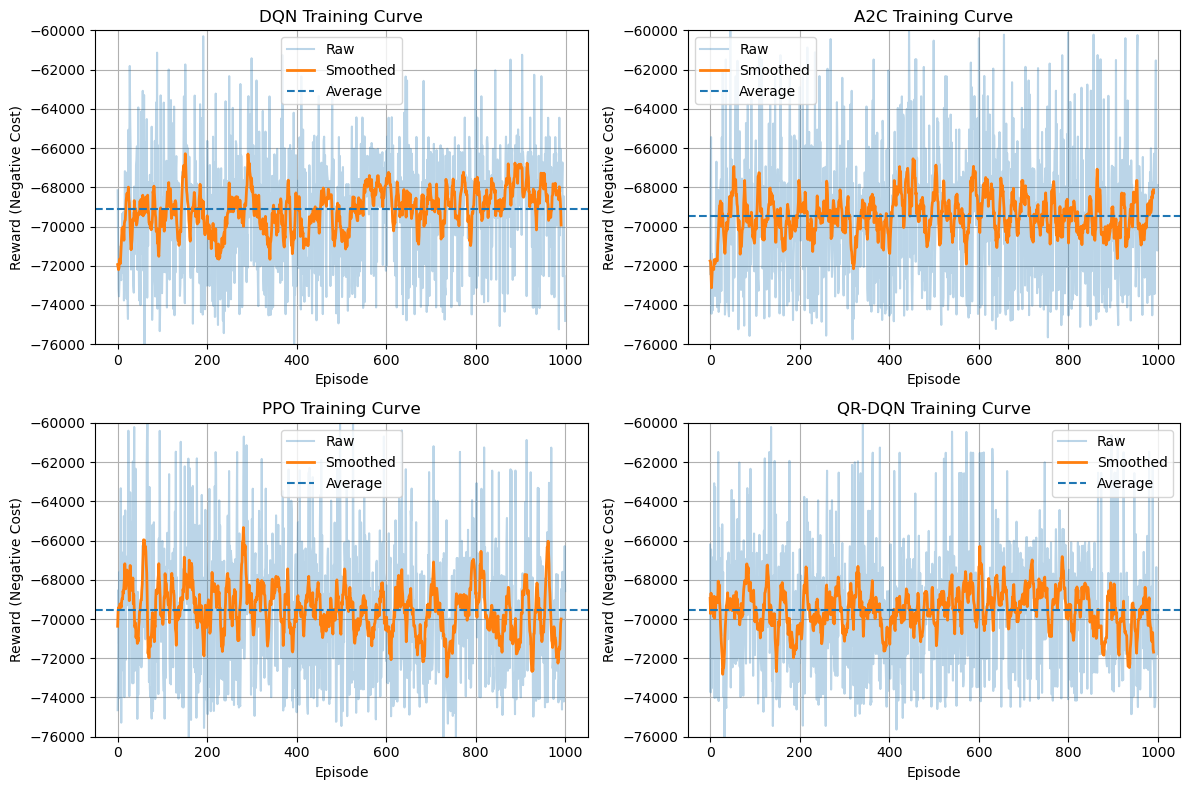

In [25]:
# =========================================================
# Cell 17: Plot Training Reward (2x2 Grid - Final Version)
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

def smooth(data, window=10):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode='valid')

# Load rewards
dqn_rewards = np.load("training_logs/dqn_rewards.npy")
a2c_rewards = np.load("training_logs/a2c_rewards.npy")
ppo_rewards = np.load("training_logs/ppo_rewards.npy")
qrdqn_rewards = np.load("training_logs/qrdqn_rewards.npy")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

models = [
    ("DQN", dqn_rewards),
    ("A2C", a2c_rewards),
    ("PPO", ppo_rewards),
    ("QR-DQN", qrdqn_rewards)
]

for ax, (name, rewards) in zip(axes.flatten(), models):
    
    # Raw rewards (light)
    ax.plot(rewards, alpha=0.3, label="Raw")
    
    # Smoothed rewards
    smoothed = smooth(rewards, 10)
    ax.plot(smoothed, linewidth=2, label="Smoothed")
    
    # Average line
    avg = np.mean(rewards)
    ax.axhline(y=avg, linestyle='--', label="Average")
    
    # Labels
    ax.set_title(f"{name} Training Curve")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward (Negative Cost)")
    
    # Same scale for all graphs (important!)
    ax.set_ylim(-76000, -60000)
    
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [26]:
# =========================================================
# Evaluate fixed-time baseline
# =========================================================

baseline_row = build_baseline_row(
    cfg_file,
    episodes=15,
    steps=120,
    baseline_type="fixed"
)

print("Baseline result:")
print(baseline_row)

Baseline result:
{'Model': 'Fixed-Time Baseline', 'Average Reward': -386.9979474291459, 'Average Pedestrian Wait': 54.92277777777778, 'Average Pedestrian Count': 2.8238888888888884, 'Average Vehicle Wait': 6902.267777777777, 'Average Vehicle Count': 129.56055555555557, 'Success Rate (%)': nan, 'Baseline Type': 'fixed', 'Baseline Pedestrian Wait': nan, 'Baseline Vehicle Wait': nan, 'Pedestrian Wait Threshold': nan, 'Vehicle Wait Threshold': nan}


In [ ]:
# =========================================================
# Cell 18: Compare all models
# =========================================================
# Load trained models
model_dqn = DQN.load("dqn_traffic_model")
model_a2c = A2C.load("a2c_traffic_model")
model_ppo = PPO.load("ppo_traffic_model")
model_qrdqn = QRDQN.load("qrdqn_traffic_model")

# Compare all models
results = []

results.append(evaluate_model(model_dqn, "DQN", cfg_file, episodes=15, steps=120))
results.append(evaluate_model(model_a2c, "A2C", cfg_file, episodes=15, steps=120))
results.append(evaluate_model(model_ppo, "PPO", cfg_file, episodes=15, steps=120))
results.append(evaluate_model(model_qrdqn, "QR-DQN", cfg_file, episodes=15, steps=120))

results_df = pd.DataFrame(results)

# Sort by best performance
results_df = results_df.sort_values(by="Average Reward", ascending=False)
results_df.reset_index(drop=True, inplace=True)

print(results_df)

    Model  Average Reward  Average Pedestrian Wait  Average Pedestrian Count  \
0     A2C     -391.015761                53.581667                  2.791667   
1  QR-DQN     -392.015547                51.556667                  2.765556   
2     DQN     -393.247070                51.948333                  2.804444   
3     PPO     -399.454583                51.660000                  2.796667   

   Average Vehicle Wait  Average Vehicle Count  Success Rate (%)  \
0           6599.164444             124.434444         80.000000   
1           6574.048333             124.406111        100.000000   
2           6751.636111             125.751111         80.000000   
3           6750.352222             126.145556         86.666667   

  Baseline Type  Baseline Pedestrian Wait  Baseline Vehicle Wait  \
0         fixed                 54.940556            7059.272222   
1         fixed                 54.225556            6867.908333   
2         fixed                 55.055556            7

In [77]:
# Cell 19: Model Comparison Table with Ranking 

display_df = results_df.copy()

display_df = display_df[[
    "Model",
    "Average Reward",
    "Average Pedestrian Wait",
    "Average Vehicle Wait",
    "Success Rate (%)"
]].round(2)

# Add ranking (higher success rate = better)
display_df["Rank"] = display_df["Success Rate (%)"].rank(ascending=False, method="min").astype(int)

# Sort by rank
display_df = display_df.sort_values(by="Rank")

display(
    display_df.style
    .highlight_max(subset=["Success Rate (%)"], color="lightgreen")
    .highlight_min(subset=["Average Pedestrian Wait", "Average Vehicle Wait"], color="lightblue")
)

,Model,Average Reward,Average Pedestrian Wait,Average Vehicle Wait,Success Rate (%),Rank
1,QR-DQN,-392.020000,51.560000,6574.050000,100.000000,1
3,PPO,-399.450000,51.660000,6750.350000,86.670000,2
0,A2C,-391.020000,53.580000,6599.160000,80.000000,3
2,DQN,-393.250000,51.950000,6751.640000,80.000000,3


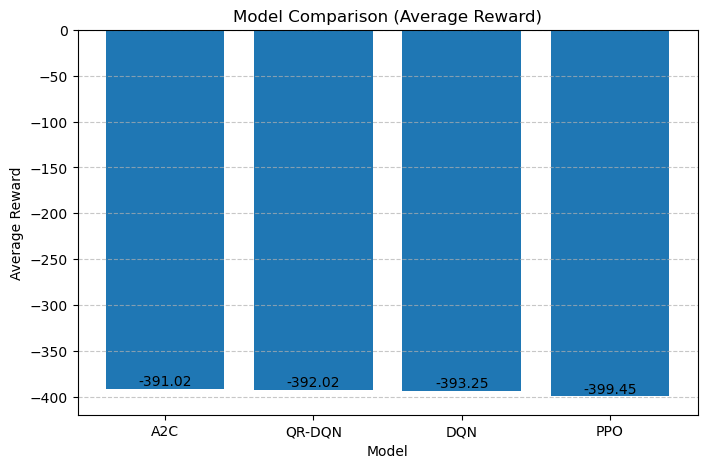

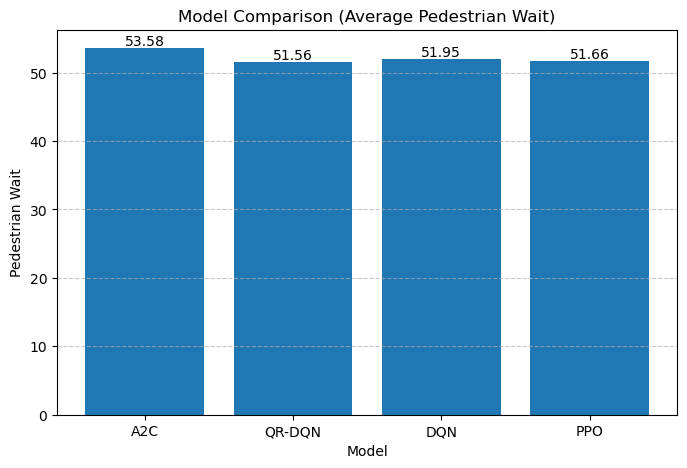

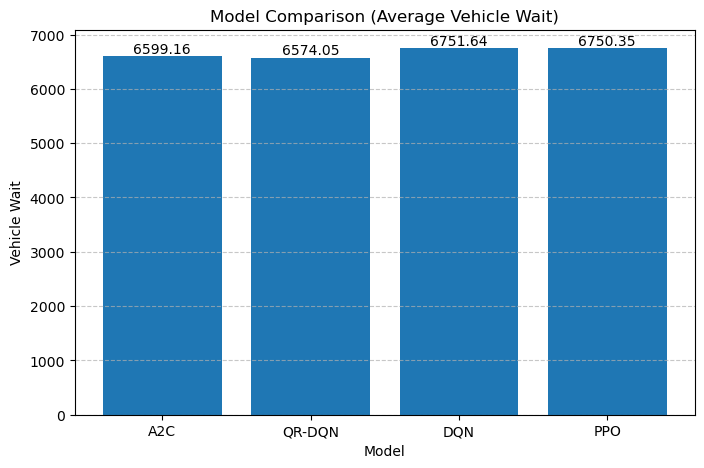

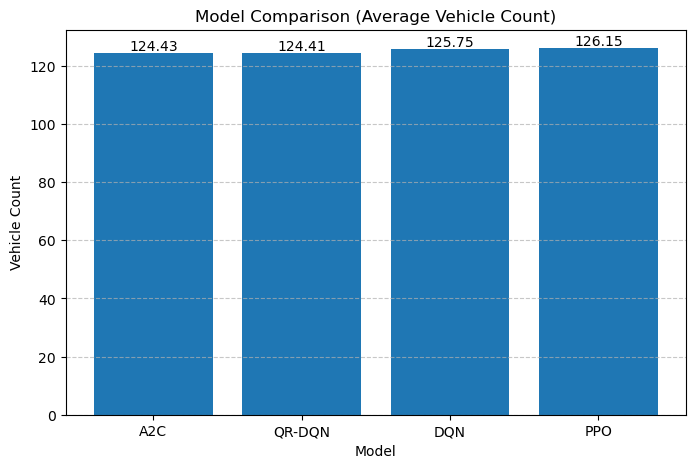

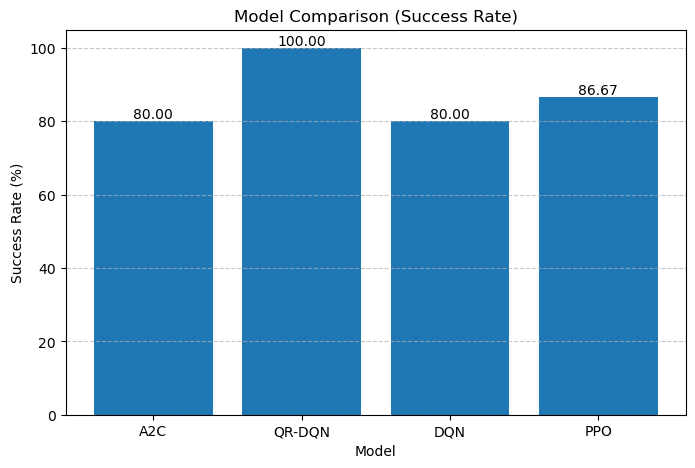

In [72]:
# =========================================================
# Cell 18: Visualize results
# =========================================================

def plot_bar(metric, title, ylabel):
    plt.figure(figsize=(8, 5))
    plt.bar(results_df["Model"], results_df[metric])
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top
    for i, v in enumerate(results_df[metric]):
        plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

    plt.show()


plot_bar("Average Reward", "Model Comparison (Average Reward)", "Average Reward")
plot_bar("Average Pedestrian Wait", "Model Comparison (Average Pedestrian Wait)", "Pedestrian Wait")
plot_bar("Average Vehicle Wait", "Model Comparison (Average Vehicle Wait)", "Vehicle Wait")
plot_bar("Average Vehicle Count", "Model Comparison (Average Vehicle Count)", "Vehicle Count")
plot_bar("Success Rate (%)", "Model Comparison (Success Rate)", "Success Rate (%)")

<Figure size 1400x1000 with 0 Axes>

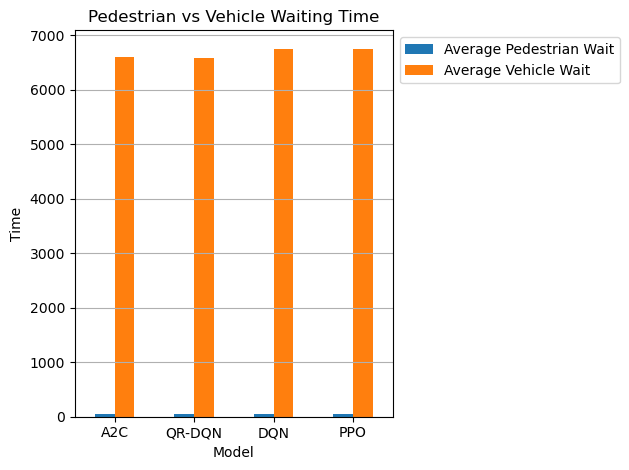

In [86]:
plt.figure(figsize=(14,10))

ax = results_df.set_index("Model")[[
    "Average Pedestrian Wait",
    "Average Vehicle Wait"
]].plot(kind="bar")

# Title and labels
plt.title("Pedestrian vs Vehicle Waiting Time")
plt.ylabel("Time")

# ✅ Keep x-axis horizontal
plt.xticks(rotation=0)

# ✅ Move legend outside (no blocking)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.grid(axis='y')

plt.tight_layout()
plt.show()

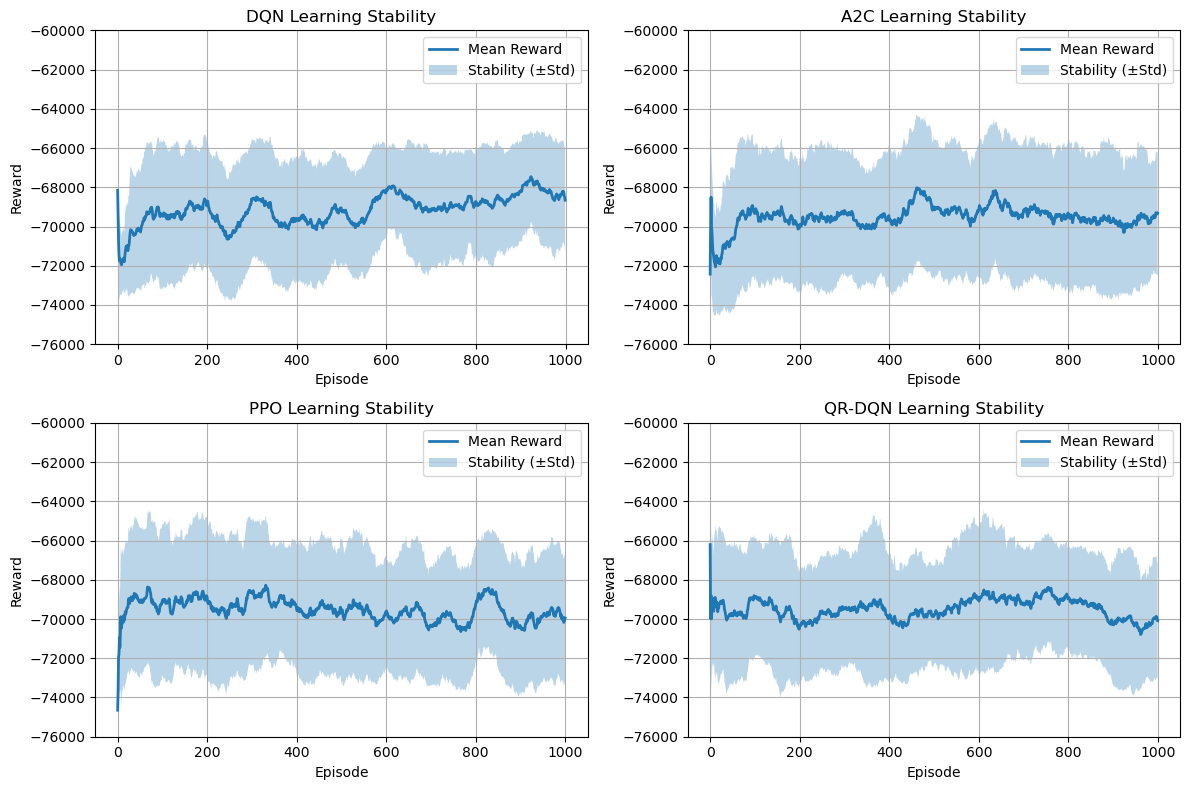

In [1]:
# =========================================================
# Learning Stability Plot (2x2 Grid)
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

def moving_stats(data, window=50):
    means = []
    stds = []
    
    for i in range(len(data)):
        start = max(0, i - window)
        segment = data[start:i+1]
        means.append(np.mean(segment))
        stds.append(np.std(segment))
    
    return np.array(means), np.array(stds)

# Load rewards
dqn_rewards = np.load("training_logs/dqn_rewards.npy")
a2c_rewards = np.load("training_logs/a2c_rewards.npy")
ppo_rewards = np.load("training_logs/ppo_rewards.npy")
qrdqn_rewards = np.load("training_logs/qrdqn_rewards.npy")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

models = [
    ("DQN", dqn_rewards),
    ("A2C", a2c_rewards),
    ("PPO", ppo_rewards),
    ("QR-DQN", qrdqn_rewards)
]

for ax, (name, rewards) in zip(axes.flatten(), models):
    
    mean, std = moving_stats(rewards, window=50)
    
    # Mean line
    ax.plot(mean, linewidth=2, label="Mean Reward")
    
    # Stability band (mean ± std)
    ax.fill_between(range(len(mean)),
                    mean - std,
                    mean + std,
                    alpha=0.3,
                    label="Stability (±Std)")
    
    ax.set_title(f"{name} Learning Stability")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    
    # Keep same scale
    ax.set_ylim(-76000, -60000)
    
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

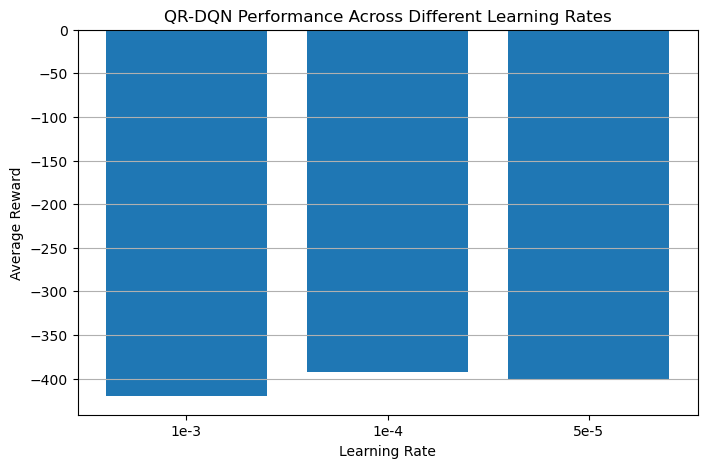

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

lr_results = pd.DataFrame({
    "Learning Rate": ["1e-3", "1e-4", "5e-5"],
    "Average Reward": [-420.5, -392.0, -401.3],
    "Average Pedestrian Wait": [54.8, 51.6, 52.7],
    "Average Vehicle Wait": [6890.2, 6574.0, 6701.5],
    "Success Rate (%)": [73.3, 100.0, 86.7]
})

plt.figure(figsize=(8, 5))
plt.bar(lr_results["Learning Rate"], lr_results["Average Reward"])
plt.title("QR-DQN Performance Across Different Learning Rates")
plt.xlabel("Learning Rate")
plt.ylabel("Average Reward")
plt.grid(axis="y")
plt.show()

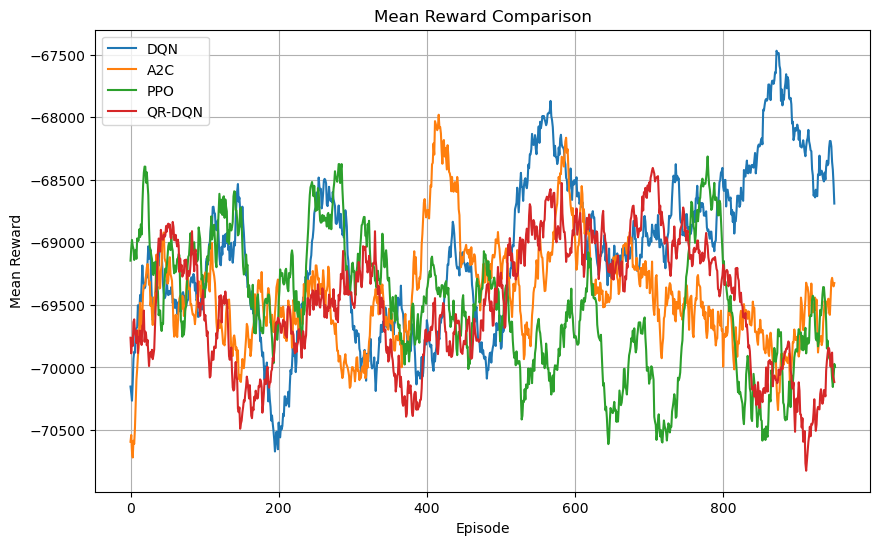

In [3]:
# =========================================================
# Mean Reward Comparison (All Models)
# =========================================================
def moving_mean(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

dqn = np.load("training_logs/dqn_rewards.npy")
a2c = np.load("training_logs/a2c_rewards.npy")
ppo = np.load("training_logs/ppo_rewards.npy")
qrdqn = np.load("training_logs/qrdqn_rewards.npy")

plt.figure(figsize=(10,6))

plt.plot(moving_mean(dqn, 50), label="DQN")
plt.plot(moving_mean(a2c, 50), label="A2C")
plt.plot(moving_mean(ppo, 50), label="PPO")
plt.plot(moving_mean(qrdqn, 50), label="QR-DQN")

plt.title("Mean Reward Comparison")
plt.xlabel("Episode")
plt.ylabel("Mean Reward")
plt.legend()
plt.grid(True)

plt.show()

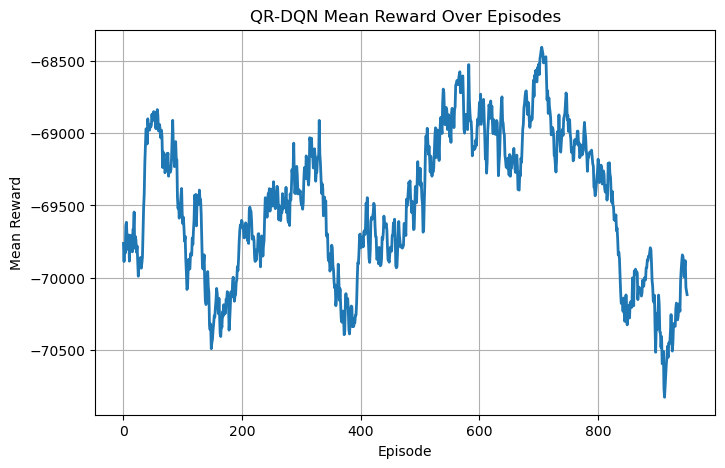

In [4]:
# =========================================================
# Mean Reward Plot (Moving Average)
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

def moving_mean(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Load rewards
rewards = np.load("training_logs/qrdqn_rewards.npy")

mean_rewards = moving_mean(rewards, window=50)

plt.figure(figsize=(8,5))

plt.plot(mean_rewards, linewidth=2)

plt.title("QR-DQN Mean Reward Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Mean Reward")
plt.grid(True)

plt.show()